### **AI-Powered Customer Churn Prediction Platform**

Business Problem

A telecom company wants to predict whether a customer will leave in the next month.


In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [50]:
import pandas as pd
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [51]:
print("Dataset preview : ")
df.head()

Dataset preview : 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [52]:
print(df.shape)

(7043, 21)


In [53]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [54]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [55]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### **Tasks**


**Phase 1**

Perform EDA

Identify:

High-risk customers,
Contract types,
Revenue trends


In [56]:
df.drop("customerID", axis=1, inplace=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [57]:
#high risk customers
high_risk = df[
    (df["Contract"] == "Month-to-month") &
    (df["MonthlyCharges"] > df["MonthlyCharges"].median()) &
    (df["tenure"] < 12)
]
print("High Risk Customers Count:", len(high_risk))
high_risk.head()

High Risk Customers Count: 770


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
31,Male,1,Yes,No,2,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),95.50,181.65,No
39,Female,0,No,No,11,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),97.85,1105.40,Yes
47,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,80.65,144.15,Yes


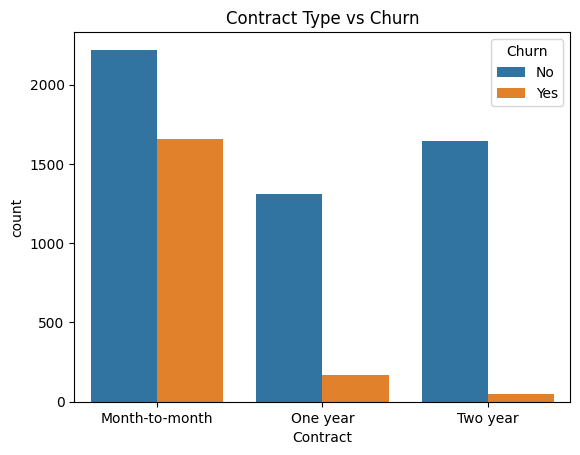

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.show()

In [59]:
contract_churn = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack()
print(contract_churn)

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


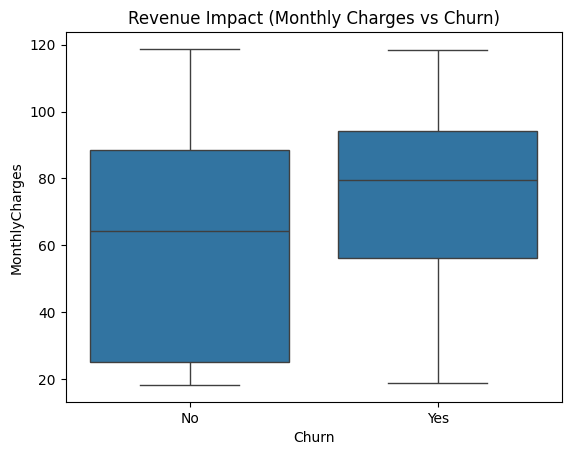

In [60]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Revenue Impact (Monthly Charges vs Churn)")
plt.show()

In [61]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
revenue_churn = df.groupby("Churn")["TotalCharges"].sum()
print(revenue_churn)

Churn
No     1.320861e+07
Yes    2.862927e+06
Name: TotalCharges, dtype: float64


**Phase 2**

Build ANN

Input:
Customer Features

Output:
Churn = Yes / No


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [63]:
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [64]:
X = df[[
    "gender",
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Contract",
    "InternetService",
    "PaymentMethod"
]]
y = df["Churn"]

In [65]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
for col in X.select_dtypes(include="object").columns:
    X[col] = le.fit_transform(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [66]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,test_size=0.2,random_state=42)

In [68]:
model = Sequential()
# Input Layer + Hidden Layer 1
model.add(Dense(16, activation="relu", input_shape=(X_train.shape[1],)))
# Hidden Layer 2
model.add(Dense(8, activation="relu"))
# Output Layer (Binary classification)
model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [70]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6998 - loss: 0.5766 - val_accuracy: 0.7693 - val_loss: 0.4891
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7726 - loss: 0.4763 - val_accuracy: 0.7941 - val_loss: 0.4389
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7795 - loss: 0.4521 - val_accuracy: 0.7888 - val_loss: 0.4261
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7883 - loss: 0.4437 - val_accuracy: 0.7844 - val_loss: 0.4216
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7919 - loss: 0.4403 - val_accuracy: 0.7879 - val_loss: 0.4170
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7914 - loss: 0.4379 - val_accuracy: 0.7862 - val_loss: 0.4142
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7925 - loss: 0.4361 - val_accuracy: 0.7826 - val_loss: 0.4123
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7945 - loss: 0.4343 - val_accuracy: 0.

In [71]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.8034066713981547
Precision: 0.6739130434782609
Recall: 0.49865951742627346


**Phase 3**

Experiment

Try:

2 hidden layers,
3 hidden layers,
5 hidden layers

Compare:

Accuracy,
Precision,
Recall


In [73]:
def build_and_train(layer_list, X_train, y_train):
    model = Sequential()
    # Input layer
    model.add(Dense(layer_list[0], activation="relu", input_shape=(X_train.shape[1],)))
    # Hidden layers
    for units in layer_list[1:]:
        model.add(Dense(units, activation="relu"))
    # Output layer
    model.add(Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    model.fit(X_train, y_train,
              epochs=20,
              batch_size=32,
              verbose=0)
    return model

In [74]:
def evaluate_model(model, X_test, y_test):
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    return acc, prec, rec

In [75]:
#model 1 : 2 hidden layers
model_2 = build_and_train([16, 8], X_train, y_train)
acc2, prec2, rec2 = evaluate_model(model_2, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [76]:
#model 2 : 3 hidden layers
model_3 = build_and_train([32, 16, 8], X_train, y_train)
acc3, prec3, rec3 = evaluate_model(model_3, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [77]:
#model 3 : 5 hidden layers
model_5 = build_and_train([64, 32, 16, 8, 4], X_train, y_train)
acc5, prec5, rec5 = evaluate_model(model_5, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [78]:
results = pd.DataFrame({
    "Model": ["2 Hidden Layers", "3 Hidden Layers", "5 Hidden Layers"],
    "Accuracy": [acc2, acc3, acc5],
    "Precision": [prec2, prec3, prec5],
    "Recall": [rec2, rec3, rec5]
})
print(results)

             Model  Accuracy  Precision    Recall
0  2 Hidden Layers  0.806955   0.690566  0.490617
1  3 Hidden Layers  0.809084   0.680556  0.525469
2  5 Hidden Layers  0.811214   0.681356  0.538874


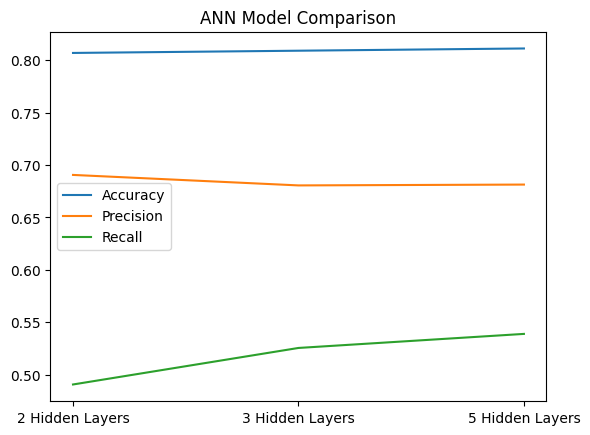

In [79]:
plt.plot(results["Model"], results["Accuracy"], label="Accuracy")
plt.plot(results["Model"], results["Precision"], label="Precision")
plt.plot(results["Model"], results["Recall"], label="Recall")
plt.title("ANN Model Comparison")
plt.legend()
plt.show()

In [80]:
model.save("model.h5")

In [81]:
from google.colab import files
files.download("model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [82]:
import pickle

pickle.dump(scaler, open("scaler.pkl", "wb"))

In [83]:
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>